# EDA Diabetes

## - Carga de datos

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [4]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## -Descripción de variables

Pregnancies. Número de embarazos del paciente (numérico)

Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)

BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)

SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)

Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)

BMI. Índice de masa corporal (numérico)

DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)

Age. Edad del paciente (numérico)

Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

## - Análisis de variable objetivo

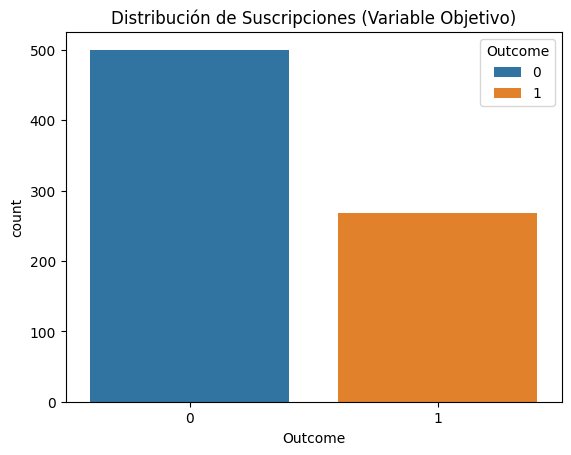

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [5]:
sns.countplot(x='Outcome', data=df, hue = 'Outcome')
plt.title('Distribución de Suscripciones (Variable Objetivo)')
plt.show()

print(df['Outcome'].value_counts(normalize=True) * 100)

La variable objetivo está desvalanceada

# - Análisis de variables numéricas (todas en realidad)

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


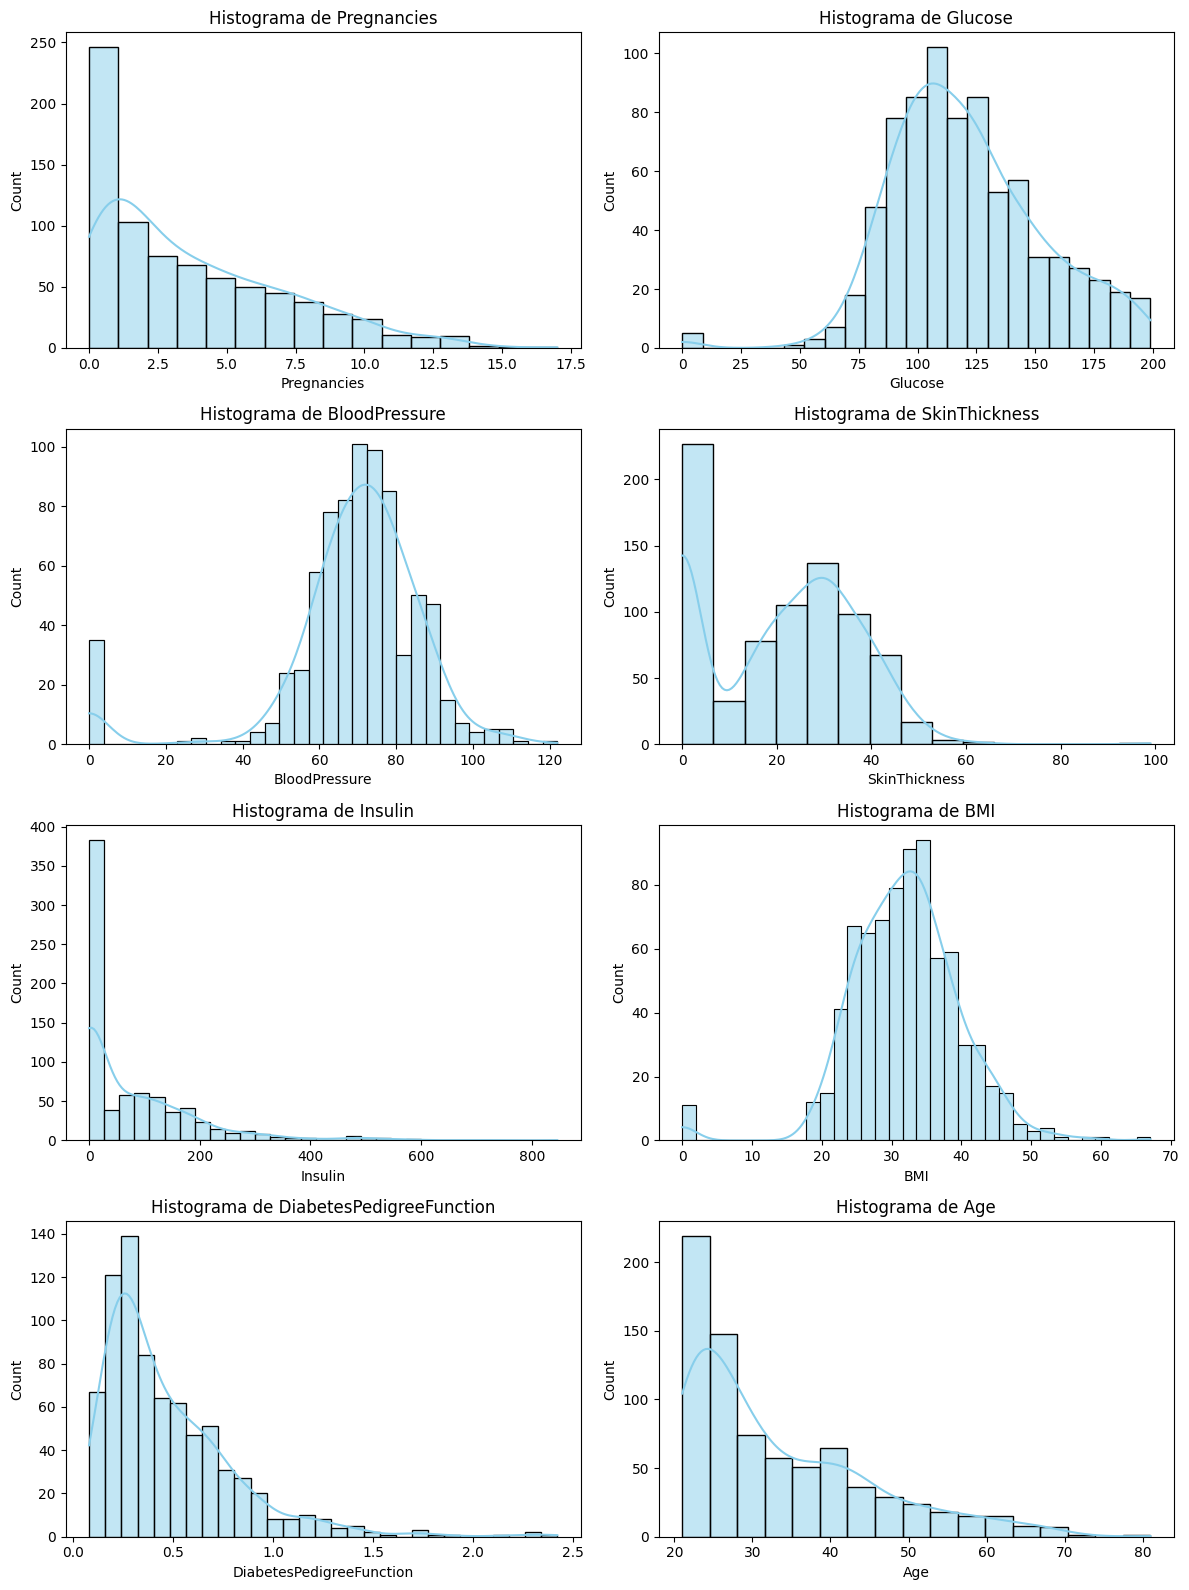

In [8]:
# Filtramos para no incluir la variable objetivo
columnas = df.columns.drop('Outcome')

# Configuramos la cuadrícula (4 filas x 2 columnas)
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten() # Aplanamos para iterar fácilmente

for i, col in enumerate(columnas):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Histograma de {col}')

plt.tight_layout()
plt.show()

In [8]:
# 1. Definimos la lista de columnas a revisar
columnas_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. Contamos cuántas filas tienen valor 0 en cada una
conteo_ceros = (df[columnas_con_ceros] == 0).sum()

print("Cantidad de valores 0 por columna:")
print(conteo_ceros)

# 3. (Opcional) Ver el porcentaje que representan esos ceros
porcentaje_ceros = (df[columnas_con_ceros] == 0).mean() * 100
print("\nPorcentaje de valores 0:")
print(porcentaje_ceros)

Cantidad de valores 0 por columna:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Porcentaje de valores 0:
Glucose           0.651042
BloodPressure     4.557292
SkinThickness    29.557292
Insulin          48.697917
BMI               1.432292
dtype: float64


In [9]:
columnas = ['BloodPressure', 'BMI', 'Glucose']

for col in columnas:
    # 1. Total de pacientes con valor 0 en la columna
    total_ceros = len(df[df[col] == 0])
    
    # 2. Pacientes con valor 0 que además tienen Outcome 1
    con_outcome_1 = len(df[(df[col] == 0) & (df['Outcome'] == 1)])
    
    # 3. Imprimir con el formato solicitado
    print(f"De los {total_ceros} pacientes con {col} en 0 y {con_outcome_1} tienen Outcome 1")

De los 35 pacientes con BloodPressure en 0 y 16 tienen Outcome 1
De los 11 pacientes con BMI en 0 y 2 tienen Outcome 1
De los 5 pacientes con Glucose en 0 y 2 tienen Outcome 1


El porcentaje de filas donde faltan valores de Glucose, Bloodpresure y BMI son bajos por lo que se optará por eliminar esas filas de la base de datos, aunque algunas de estas filas correspondan a pacientes con diabetes (Outcome 1). Otra opción sería reemplazar los valores faltantes por la mediana de la variable, o reemplazar el valor faltante imputándole un valor por la correlación con otra variable que tenga los datos completos y algo de correlación; pero se considera que por lo escaso de los datos se prefiere mantener la veracidad de la base de datos.

In [9]:
# 1. Identificamos los índices de las filas que tienen 0 en alguna de las tres columnas
indices_a_eliminar = df[(df['Glucose'] == 0) | (df['BMI'] == 0) | (df['BloodPressure'] == 0)].index

# 2. Eliminamos esas filas del DataFrame original
df.drop(indices_a_eliminar, inplace=True)

# 3. Verificamos cuántas filas quedaron
print(f"Filas restantes en el dataset: {len(df)}")

# 4. Confirmación rápida de que ya no hay ceros en esas columnas
print("\nConteo de ceros actual:")
print((df[['Glucose', 'BMI', 'BloodPressure']] == 0).sum())

Filas restantes en el dataset: 724

Conteo de ceros actual:
Glucose          0
BMI              0
BloodPressure    0
dtype: int64


In [10]:
# 1. Contar cuántos ceros quedan en SkinThickness
total_filas_actuales = len(df)
ceros_skinthickness = (df['SkinThickness'] == 0).sum()
ceros_insulin = (df['Insulin'] == 0).sum()

# 2. Calcular el porcentaje respecto al nuevo total
porcentaje_skinthickness = (ceros_skinthickness / total_filas_actuales) * 100
porcentaje_insulin = (ceros_insulin / total_filas_actuales) * 100

print(f"Cantidad de valores 0 en SkinThickness: {ceros_skinthickness}")
print(f"Porcentaje sobre el total del dataset limpio: {porcentaje_skinthickness:.2f}%")
print()
print(f"Cantidad de valores 0 en Insuline: {ceros_insulin}")
print(f"Porcentaje sobre el total del dataset limpio: {porcentaje_insulin:.2f}%")

Cantidad de valores 0 en SkinThickness: 192
Porcentaje sobre el total del dataset limpio: 26.52%

Cantidad de valores 0 en Insuline: 332
Porcentaje sobre el total del dataset limpio: 45.86%


En el caso de la variable Insuline (insulina sérica de 2 horas) la cantidad de datos faltante es casi la mitad, demasiado alta (332 valores de 724), por lo que no se recomendaría prescindir de esa contidad de datos.

En la variable SkinThickness (grosor del pliegue cutáneo del tríceps) la cantidad de datos faltante es cercana a la cuarte parte, muy alta (192 valores de 724), por lo que no se recomendaría prescindir de esos datos.

La recomendación es eliminar estas dos columnas de la base de datos.

Si se decidiera prescindir de esta gran cantidad de datos primero habría que probar que las relaciones existentes previamente entre variables no se modifique sensiblemente.



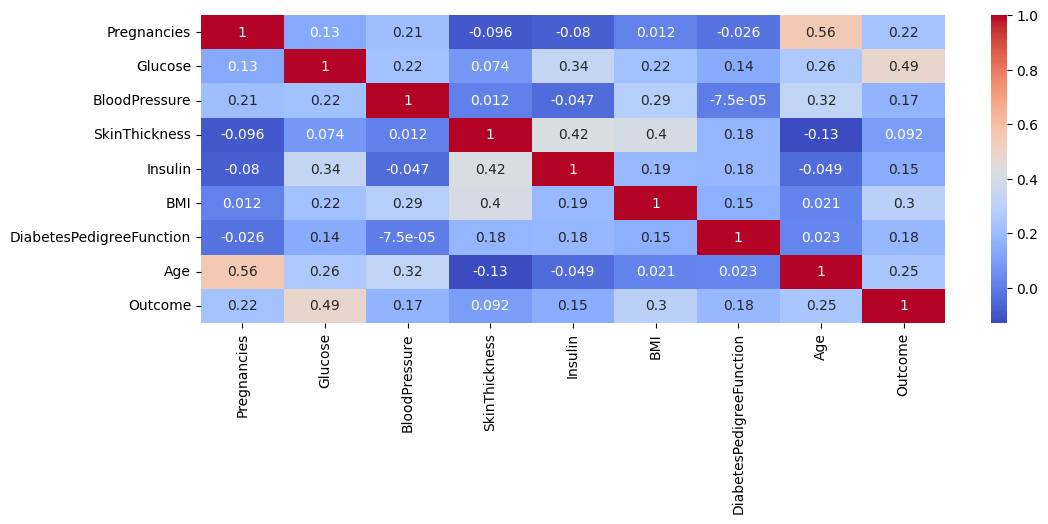

In [11]:
corr_original = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12,4))
sns.heatmap(corr_original, annot=True, cmap="coolwarm", ax=ax)
plt.show()

Los valores de correlación de SkinThickness e Insulin se deben tomar con precaución ya que pueden compartir valores 0 con otra variable y dar una falsa impresión de que los valores están relacionados entre ellos y viceversa, puede que no muestre correlación cuando en realidad sí la pueden tenerla.

En las otras columnas con datos faltantes, se observa que los valores de BloodPresure tienen baja correlación con la edad (R2 0.24), parecido a los de Glucose (0.26), y en los de BMI no muestran correlación con ninguna varible que no tenga datos faltantes.

## Prueba de para evaluar el DF sin los valores de SkinThickness e Insulin

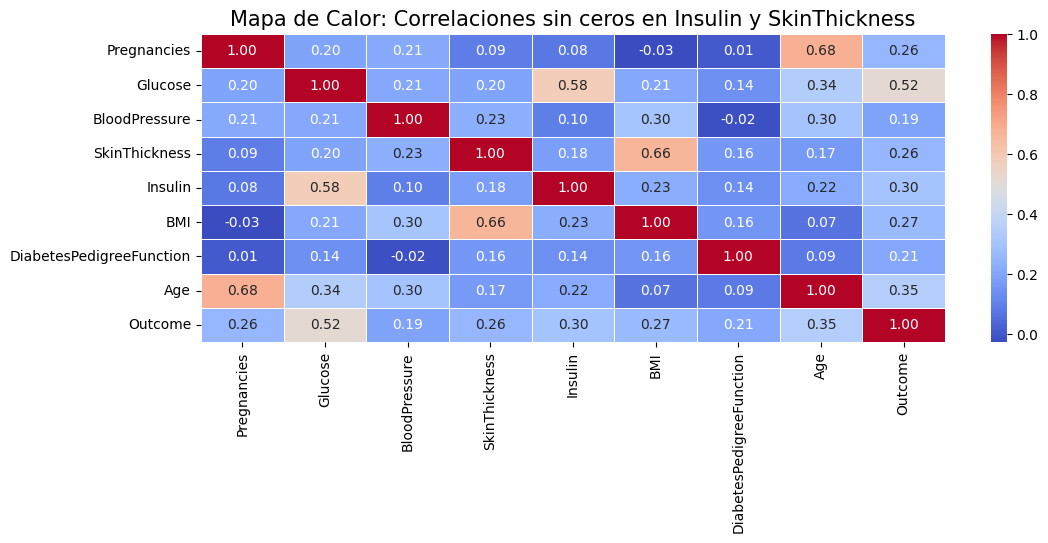

Registros originales: 724
Registros después de eliminar ceros: 392


In [12]:
# 1. Creamos una copia filtrada eliminando los ceros de Insulin y SkinThickness
df_filtrado = df[(df['Insulin'] > 0) & (df['SkinThickness'] > 0)].copy()

# 2. Calculamos la matriz de correlación del nuevo set de datos
corr_filtrado = df_filtrado.corr()

# 3. Graficamos el Heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(
    corr_filtrado, 
    annot=True,      # Muestra los números de correlación
    cmap='coolwarm', # Rojo positivo, azul negativo
    fmt=".2f",       # Dos decimales
    linewidths=0.5
)

plt.title('Mapa de Calor: Correlaciones sin ceros en Insulin y SkinThickness', fontsize=15)
plt.show()

# 4. Verificamos cuántos datos nos quedaron tras el recorte
print(f"Registros originales: {len(df)}")
print(f"Registros después de eliminar ceros: {len(df_filtrado)}")

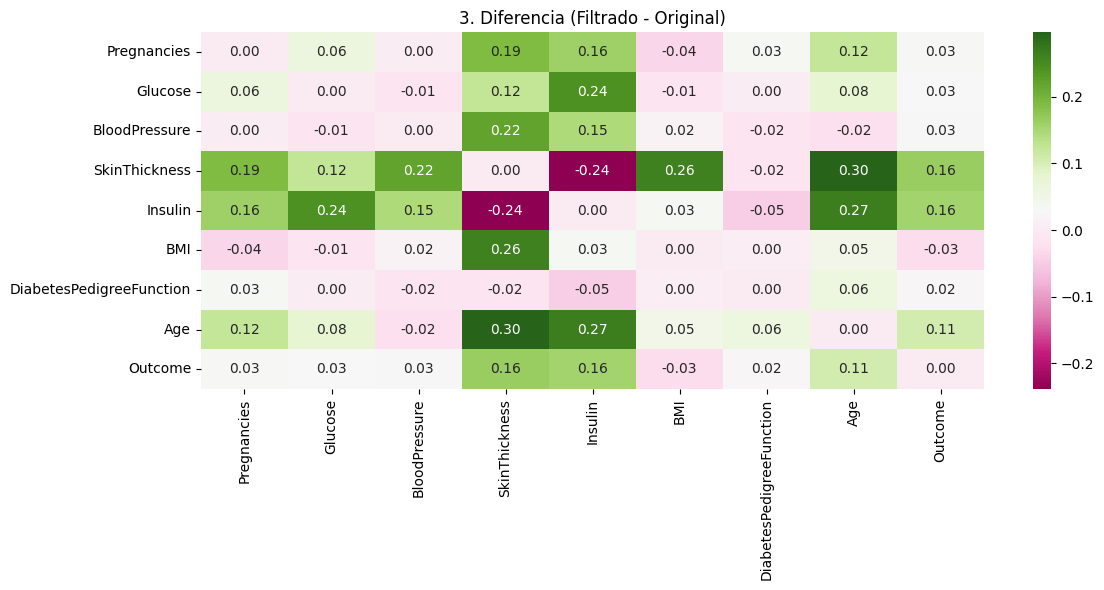

In [13]:
corr_diff = corr_filtrado - corr_original

plt.figure(figsize=(12, 6))
sns.heatmap(corr_diff, annot=True, fmt=".2f", cmap='PiYG')
plt.title('3. Diferencia (Filtrado - Original)')

plt.tight_layout()
plt.show()

In [137]:
df_filtrado.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,3.301020,122.627551,70.663265,29.145408,156.056122,33.086224,0.523046,30.864796,0.331633
std,3.211424,30.860781,12.496092,10.516424,118.841690,7.027659,0.345488,10.200777,0.471401
min,0.000000,56.000000,24.000000,7.000000,14.000000,18.200000,0.085000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,21.000000,76.750000,28.400000,0.269750,23.000000,0.000000
50%,2.000000,119.000000,70.000000,29.000000,125.500000,33.200000,0.449500,27.000000,0.000000
75%,5.000000,143.000000,78.000000,37.000000,190.000000,37.100000,0.687000,36.000000,1.000000
max,17.000000,198.000000,110.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


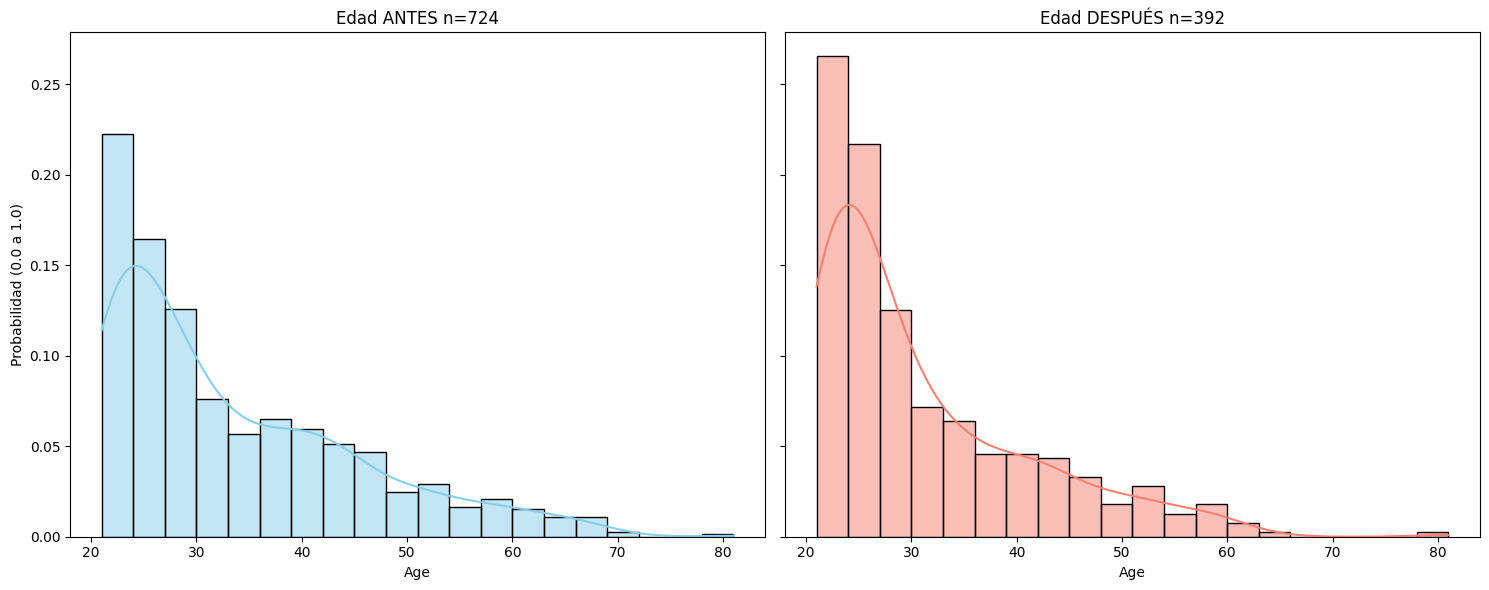

In [14]:
# 1. Configurar el espacio para dos gráficos comparativos
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# 2. Histograma Relativo - ANTES
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue', 
             bins=20, stat='probability') # <--- Frecuencia relativa
axes[0].set_title(f'Edad ANTES n={len(df)}')
axes[0].set_ylabel('Probabilidad (0.0 a 1.0)')

# 3. Histograma Relativo - DESPUÉS
sns.histplot(df_filtrado['Age'], kde=True, ax=axes[1], color='salmon', 
             bins=20, stat='probability') # <--- Frecuencia relativa
axes[1].set_title(f'Edad DESPUÉS n={len(df_filtrado)}')

plt.tight_layout()
plt.show()

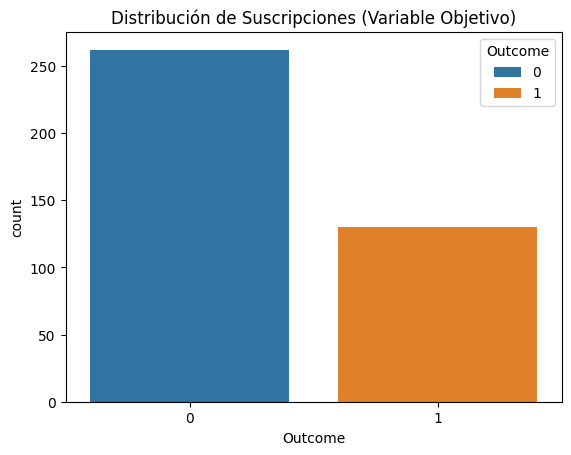

Outcome
0    65.607735
1    34.392265
Name: proportion, dtype: float64


In [15]:
sns.countplot(x='Outcome', data=df_filtrado, hue = 'Outcome')
plt.title('Distribución de Suscripciones (Variable Objetivo)')
plt.show()

print(df['Outcome'].value_counts(normalize=True) * 100)

El el df filtrado la correlación entre Outcome y Skinthickness paso de 0.092 (sin correlación) a 0.26 (algo de correlación) y en el caso de Insuline, 0.15 a 0.3 (hay correlación, aunque débil).

Por otra parte Insuline muestra ahora una buena correlación (real) con Glucose y SkinThickness con BMI.

La supuesta correlación entre Insulin y SkinThickness se elimina.

Lo resaltante de la base de datos filtrada es que no cambiaron sensiblemente ninguna de las correlaciones entre las demás variables (cambios en R2 entre -0.03 y 0.02 en general).

La única variable que varió un poco más sus correlaciones es "age" que varió entre -0.02 y 0.12 (con pregnancies), particularmente aumentó si correlación con Outcome 0.11. Sim embargo, sus histogramas no son muy diferentes aunque el promedio de edad haya pasado de 33 a 31 años.

Por último y de gran importancia es que la proporción de la variable objetivo se mantuvo casi igual, cerca del 65%.

## Análisis multivariado para la variable Outcome

A continuación se muestra los gráficos de la principales variables que tienen mayor correlación con Glucose, luego Age y por último BMI.

Se observa que donde se discrimina mejor la viable Outcome es el gráfico de Glucosa vs Age.

Por último, en los gráficos de caja y bigote, se noto como la variable Glucosa es la que mejor discrimina Outcome, seguida de BMI.

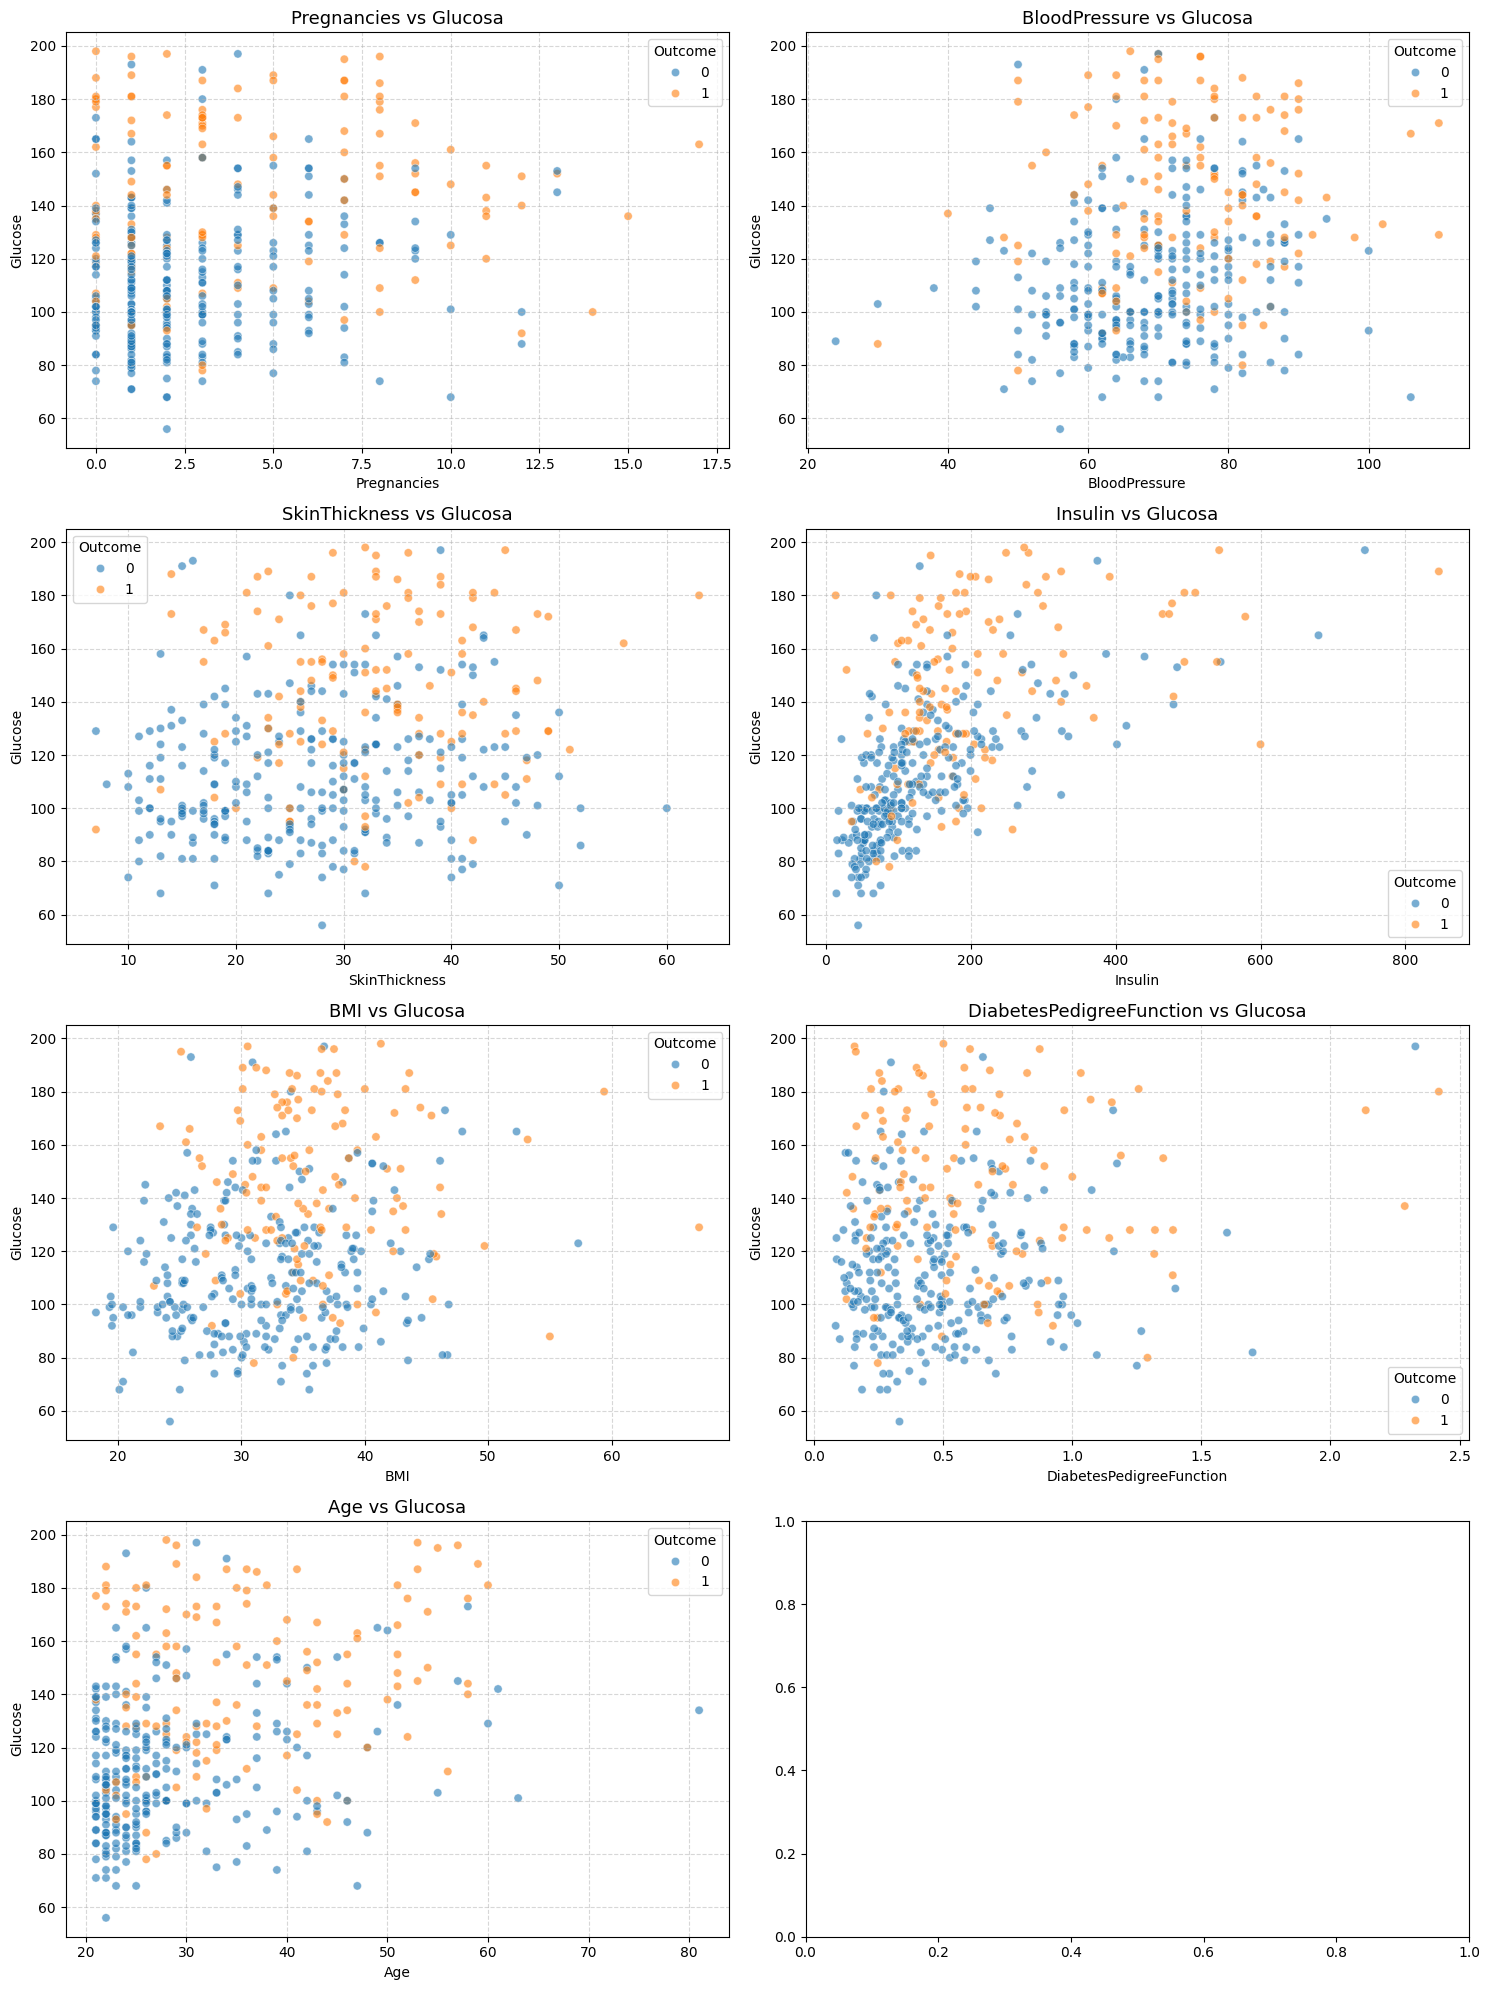

In [16]:
# 1. Definimos las variables a comparar (todas menos Insulin y Outcome)
columnas_comparar = df_filtrado.columns.drop(['Glucose', 'Outcome'])

# 2. Configuramos la cuadrícula (4 filas x 2 columnas)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

# 3. Creamos un Scatter Plot para cada relación
for i, col in enumerate(columnas_comparar):
    sns.scatterplot(
        data=df_filtrado, 
        x=col, 
        y='Glucose', 
        hue='Outcome', 
        ax=axes[i], 
        alpha=0.6
    )
    axes[i].set_title(f'{col} vs Glucosa', fontsize=13)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

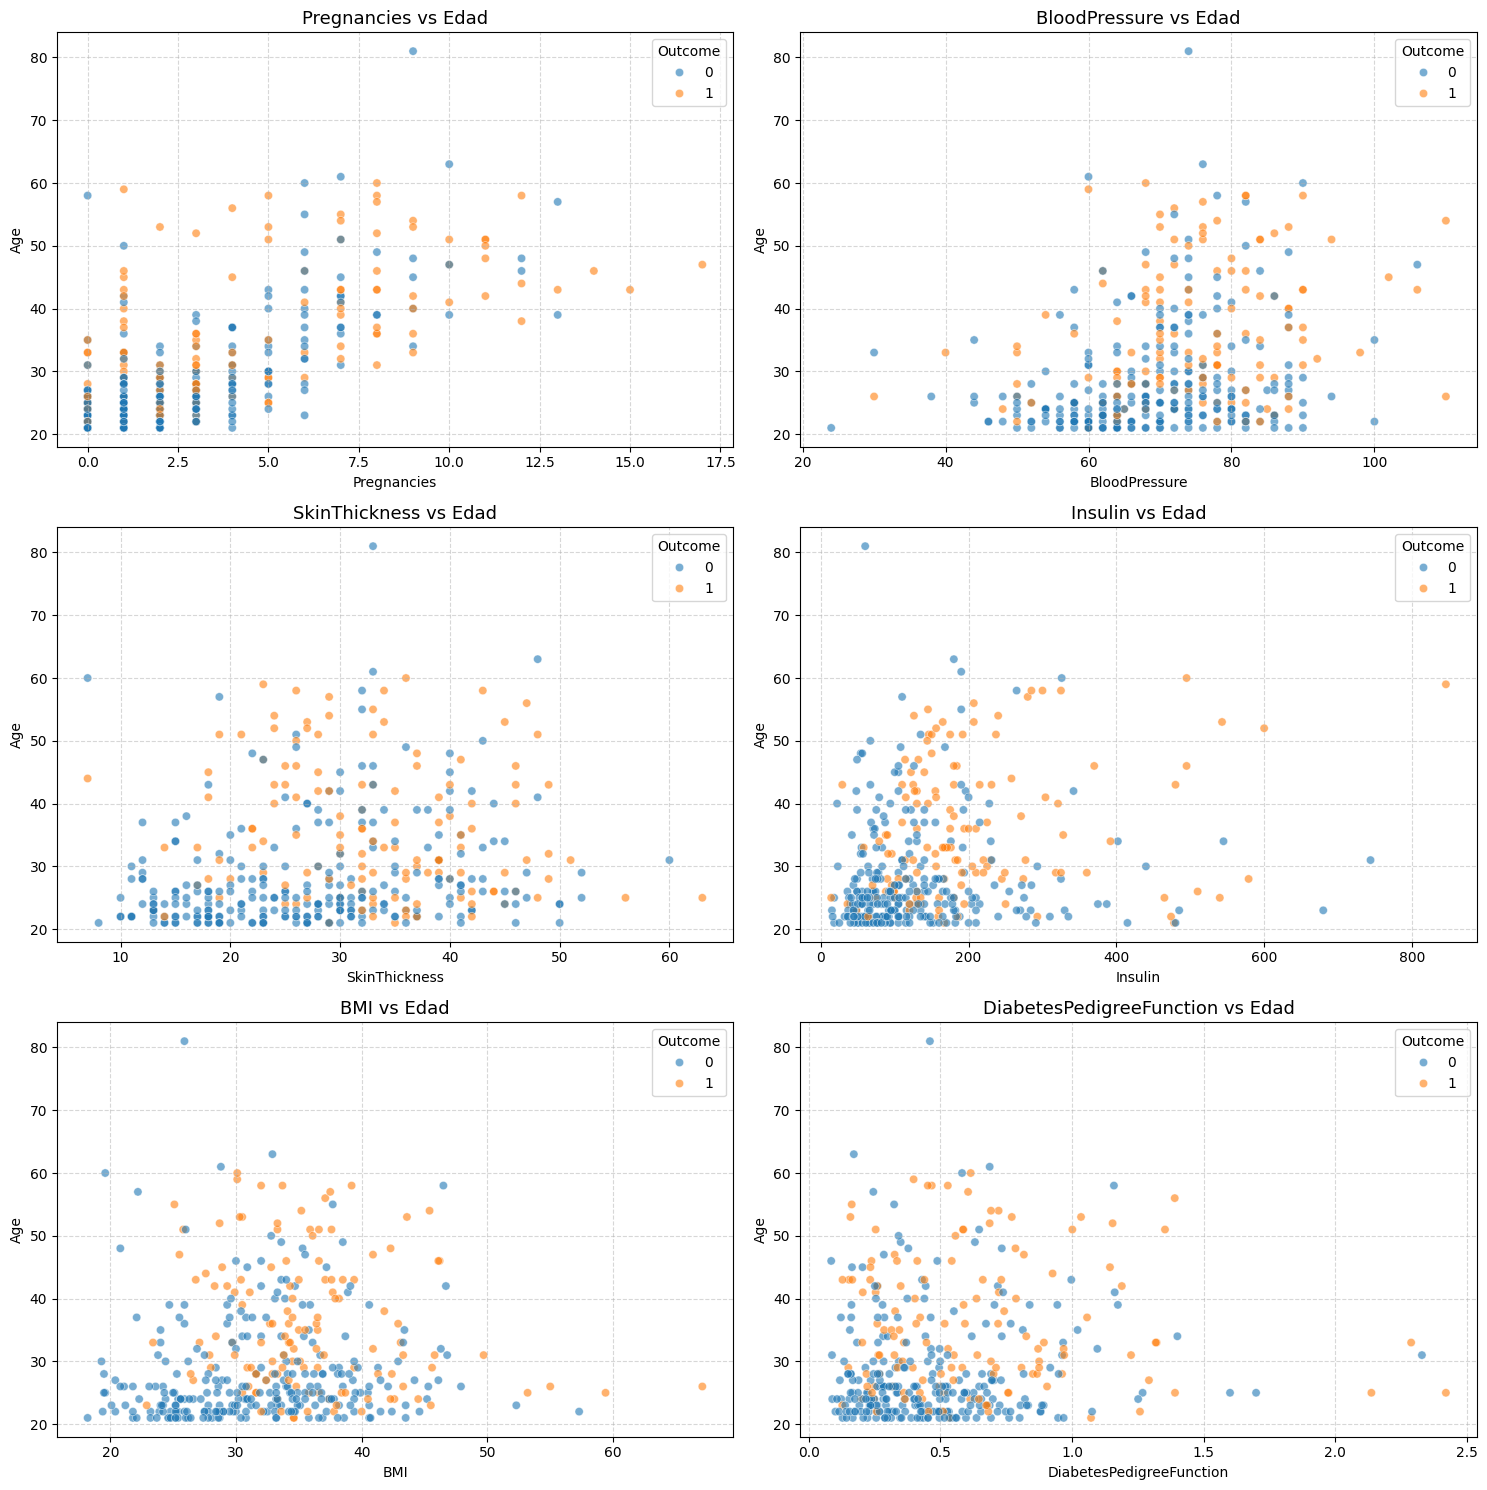

In [17]:
# 1. Definimos las variables a comparar (todas menos SkinThickness y Outcome)
columnas_comparar2 = df_filtrado.columns.drop(['Age', "Glucose", 'Outcome'])

# 2. Configuramos la cuadrícula (4 filas x 2 columnas)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

# 3. Creamos un Scatter Plot para cada relación
for i, col in enumerate(columnas_comparar2):
    sns.scatterplot(
        data=df_filtrado, 
        x=col, 
        y='Age', 
        hue='Outcome', 
        ax=axes[i], 
        alpha=0.6
    )
    axes[i].set_title(f'{col} vs Edad', fontsize=13)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

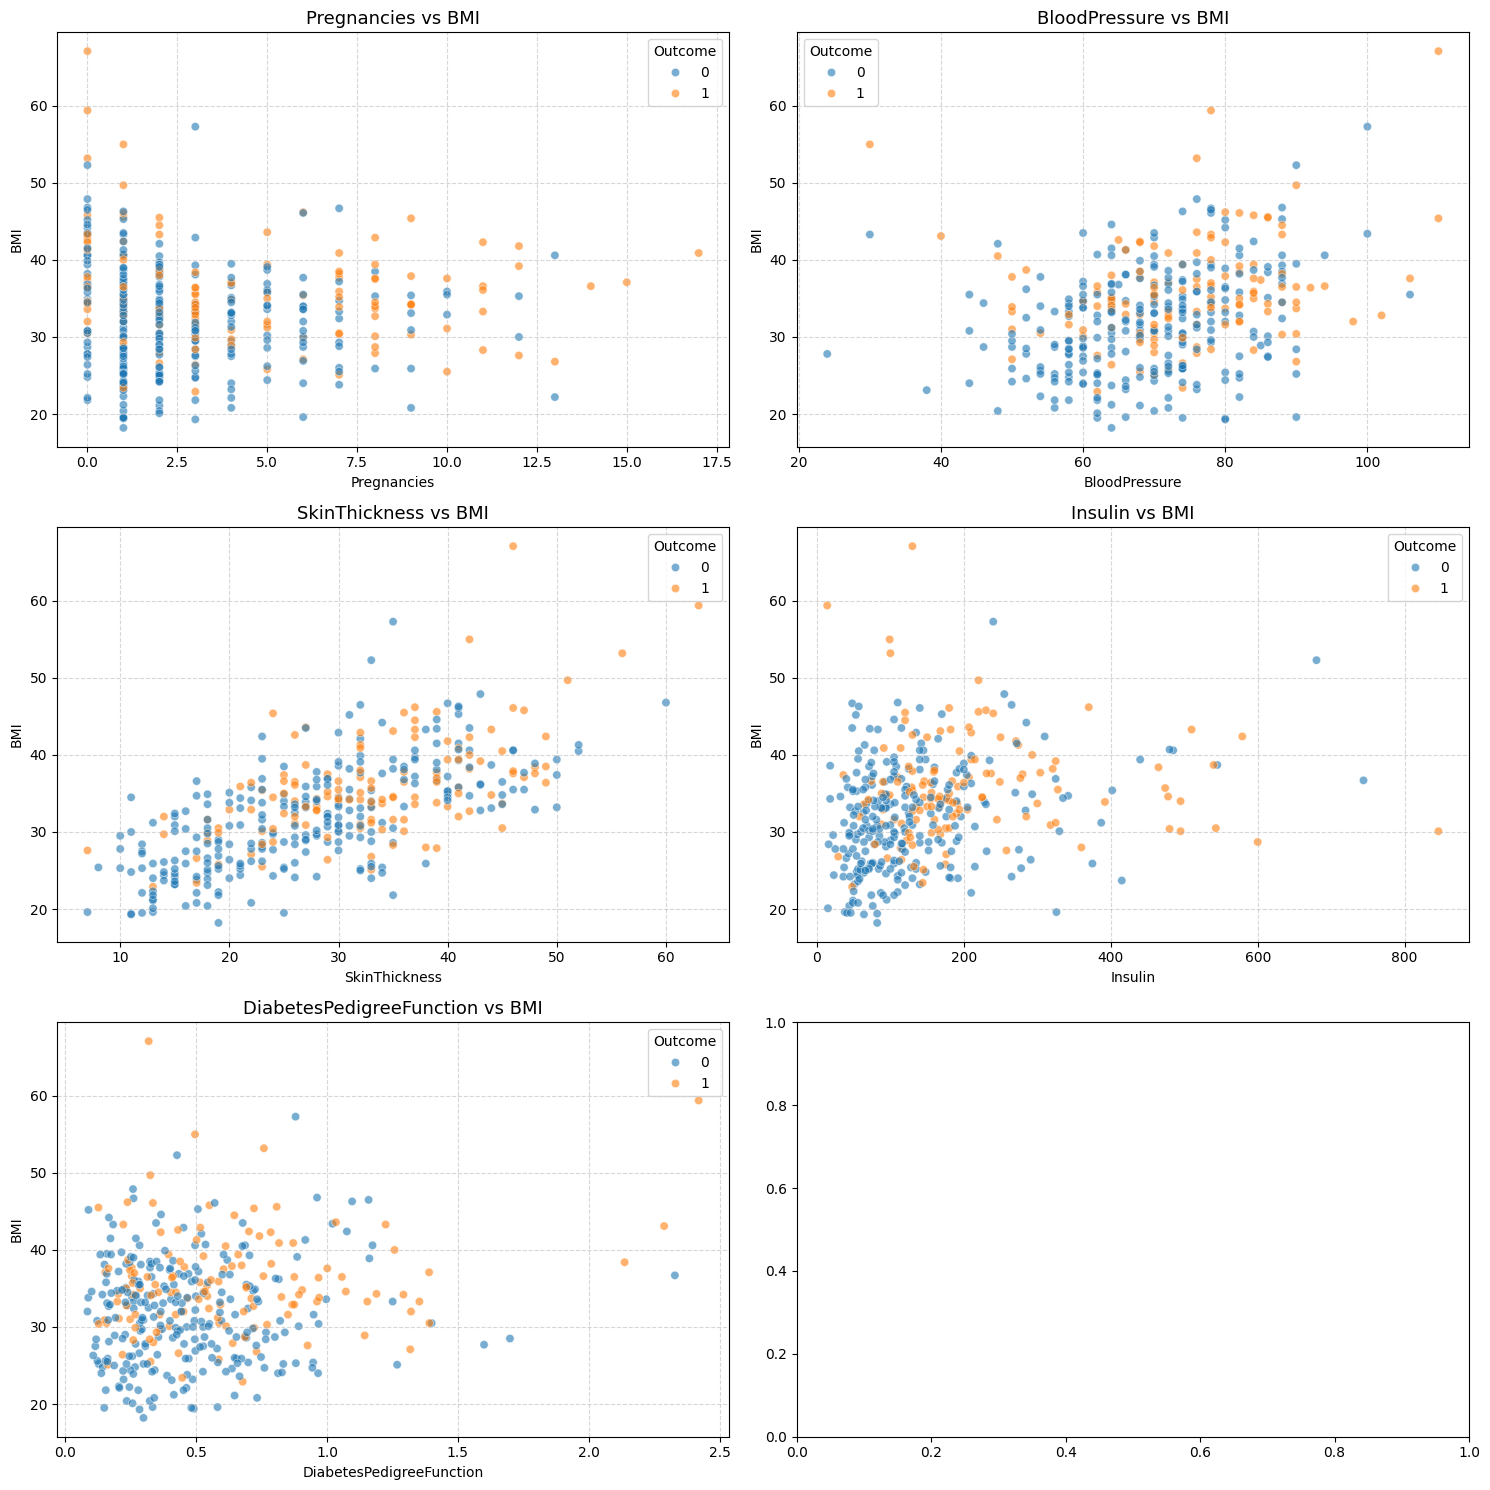

In [18]:
# 1. Definimos las variables a comparar (todas menos SkinThickness y Outcome)
columnas_comparar2 = df_filtrado.columns.drop(['BMI', 'Age', 'Glucose', 'Outcome'])

# 2. Configuramos la cuadrícula (4 filas x 2 columnas)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

# 3. Creamos un Scatter Plot para cada relación
for i, col in enumerate(columnas_comparar2):
    sns.scatterplot(
        data=df_filtrado, 
        x=col, 
        y='BMI', 
        hue='Outcome', 
        ax=axes[i], 
        alpha=0.6
    )
    axes[i].set_title(f'{col} vs BMI', fontsize=13)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

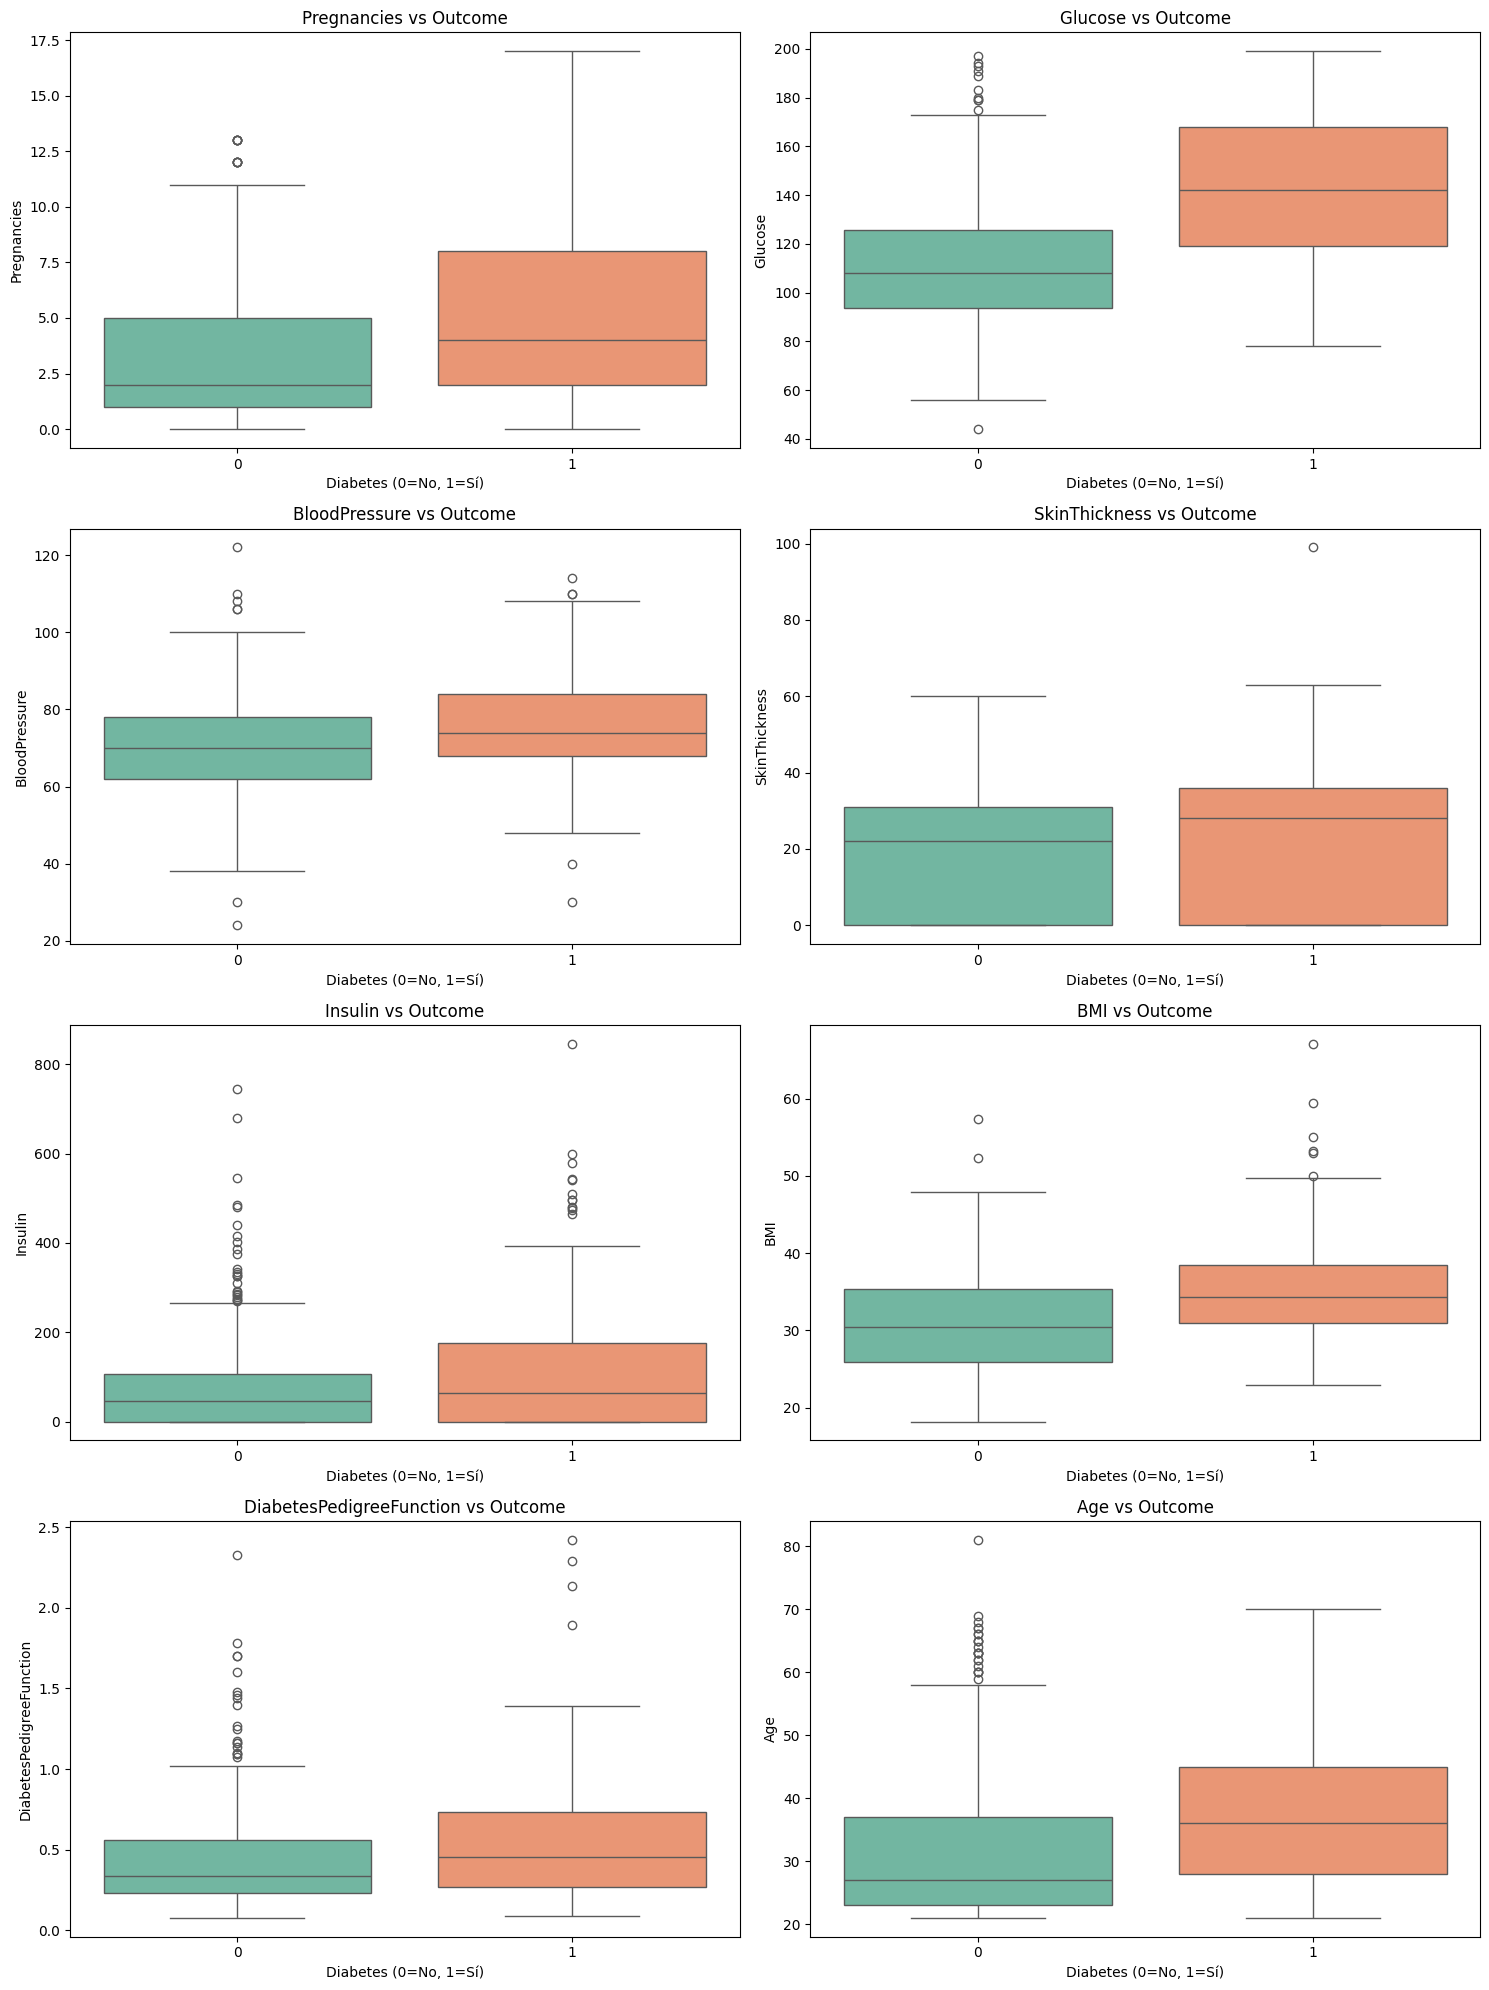

In [19]:
# 1. Definimos las variables numéricas (excluyendo Outcome)
columnas_estudio = df_filtrado.columns.drop('Outcome')

# 2. Configuramos la cuadrícula
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

# 3. Creamos el Boxplot con la nueva sintaxis de Seaborn
for i, col in enumerate(columnas_estudio):
    sns.boxplot(
        data=df, 
        x='Outcome', 
        y=col, 
        ax=axes[i], 
        hue='Outcome',      # Asignamos el color a la variable X
        legend=False,       # Quitamos la leyenda para que no estorbe
        palette='Set2'
    )
    axes[i].set_title(f'{col} vs Outcome', fontsize=12)
    axes[i].set_xlabel('Diabetes (0=No, 1=Sí)')

plt.tight_layout()
plt.show()

La correlación entre la variable objetivo y SkinThickness